# SSD 目标检测：从零开始的完整实现教程

### 项目背景与算法简介
**SSD (Single Shot MultiBox Detector)** 是计算机视觉领域极具代表性的一阶段（One-stage）目标检测算法。与需要先提取候选区域（Region Proposal）的二阶段算法（如 Faster R-CNN）不同，SSD 将检测任务转化为一个回归问题，直接在特征图上预测物体的分类和边界框方位。

**SSD 的核心特性：**
1.  **多尺度预测（Multi-scale Features）：** 在网络的不同深度提取特征图，分别负责检测不同大小的物体（浅层检测小物体，深层检测大物体）。
2.  **先验框机制（Default Boxes/Priors）：** 在每个像素点预设不同比例的候选框，简化回归难度。
3.  **计算高效：** 兼顾了实时检测的速度与主流算法的精度。

### 项目目标
本项目的目的是通过 PyTorch 实现一个完整的 SSD 推理与训练流程。我们将涵盖：
- 检测环境与数据集的自动化校验。
- 复杂配置参数的结构化设计。
- 核心组件（先验框生成、损失函数、硬负样本采样）的逻辑实现。
- VGG16 骨干网络与多尺度检测头的构建。
- 推理结果的后处理逻辑与结果可视化。

---
## 第一部分：环境准备与探索性数据分析 (EDA)
首先，我们需要导入深度学习必需的库，并确认计算设备（CPU/GPU）状态。

### 步骤 1.1：库导入
我们将使用 `torch` 处理张量运算，`torchvision` 提供基础操作，`cv2` 与 `PIL` 处理图像，并利用 `matplotlib` 进行结果展示。此外，`xml.etree.ElementTree` 是解析 PASCAL VOC 数据集标注的关键。

In [20]:
import math
import os
import xml.etree.ElementTree as ET
import warnings
from itertools import product
from math import sqrt
from types import SimpleNamespace

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataloader import default_collate
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("Libraries imported.")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported.
PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


### 步骤 1.2：计算设备与数据集路径设置
我们将自动检测显卡是否可用。同时，定义 `VOC_ROOT` 指向数据集目录。PASCAL VOC 是目标检测的基准数据集，其结构包含图片（JPEGImages）和对应的 XML 标注（Annotations）。我们将路径存入环境变量，方便后续数据加载器调用。

In [21]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Dataset root (SSD-master expects VOC2007/VOC2012 under VOC_ROOT)
VOC_ROOT = os.path.join(os.getcwd(), "datasets", "VOCdevkit")
os.environ["VOC_ROOT"] = VOC_ROOT
print(f"VOC_ROOT: {VOC_ROOT}")

# Output directory
os.makedirs("outputs", exist_ok=True)
print("Output dir: outputs/")

Device: cuda
VOC_ROOT: d:\MyCode\anli\29.SSD\datasets\VOCdevkit
Output dir: outputs/


### 步骤 1.3：数据集完整性校验
在开始训练前，必须确保本地数据集的文件夹结构正确。我们将检查 `VOC2007` 的核心目录及包含训练/测试列表的 `txt` 文件，避免因路径错误导致程序崩溃。

In [22]:
def validate_voc_dataset(root_path):
    """Validate VOC dataset structure under VOC_ROOT."""
    voc2007_dir = os.path.join(root_path, "VOC2007")
    voc2012_dir = os.path.join(root_path, "VOC2012")
    required_dirs = [
        "JPEGImages",
        "Annotations",
        os.path.join("ImageSets", "Main"),
    ]
    required_files = [
        os.path.join("ImageSets", "Main", "trainval.txt"),
        os.path.join("ImageSets", "Main", "test.txt"),
    ]

    print("Checking VOC2007...")
    print("=" * 50)
    if not os.path.exists(voc2007_dir):
        print(f"Missing: {voc2007_dir}")
        return False

    status = True
    for req_dir in required_dirs:
        dir_path = os.path.join(voc2007_dir, req_dir)
        if os.path.exists(dir_path):
            print(f"OK  {req_dir}")
        else:
            print(f"MISS {req_dir}")
            status = False

    print()
    for req_file in required_files:
        file_path = os.path.join(voc2007_dir, req_file)
        if os.path.exists(file_path):
            with open(file_path) as f:
                count = len(f.readlines())
            print(f"OK  {req_file} ({count} images)")
        else:
            print(f"MISS {req_file}")
            status = False

    if os.path.exists(voc2012_dir):
        print("=" * 50)
        print("Found VOC2012 (optional).")
    else:
        print("=" * 50)
        print("VOC2012 not found (optional).")

    if status:
        num_images = len(os.listdir(os.path.join(voc2007_dir, "JPEGImages")))
        num_annotations = len(os.listdir(os.path.join(voc2007_dir, "Annotations")))
        print(f"VOC2007 images: {num_images}")
        print(f"VOC2007 annotations: {num_annotations}")
    else:
        print("VOC2007 validation failed.")

    return status

dataset_valid = validate_voc_dataset(VOC_ROOT)

Checking VOC2007...
OK  JPEGImages
OK  Annotations
OK  ImageSets\Main

OK  ImageSets\Main\trainval.txt (5011 images)
OK  ImageSets\Main\test.txt (4952 images)
VOC2012 not found (optional).
VOC2007 images: 9963
VOC2007 annotations: 9963


### 步骤 1.4：原始数据可视化观察
这一步非常重要，它能帮助我们直观理解标注数据：
1. 从 `trainval.txt` 中随机抽取一张图片。
2. 解析对应的 XML 文件以提取边界框（Bounding Box）。
3. 使用 `matplotlib` 将图片与真实框（Ground Truth）绘制在一起。这将验证我们的坐标读取逻辑是否正确。

Showing a VOC2007 sample...


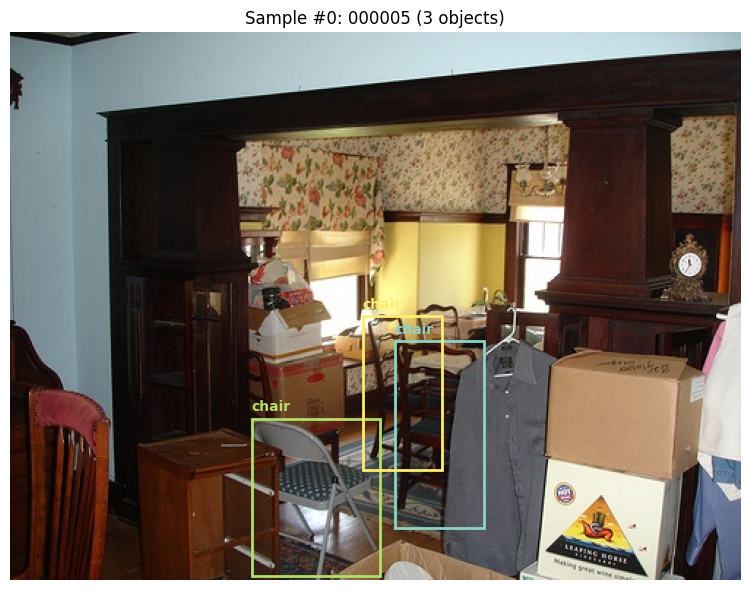

Image size: 500 x 375
  1. chair           - (263, 211) to (324, 339)
  2. chair           - (165, 264) to (253, 372)
  3. chair           - (241, 194) to (295, 299)


In [23]:
def show_sample(voc_root, sample_idx=0):
    """Show one VOC2007 sample with boxes."""
    voc2007_dir = os.path.join(voc_root, "VOC2007")
    with open(os.path.join(voc2007_dir, "ImageSets", "Main", "trainval.txt")) as f:
        image_ids = [line.strip() for line in f.readlines()]
    img_id = image_ids[sample_idx]
    img_path = os.path.join(voc2007_dir, "JPEGImages", f"{img_id}.jpg")
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    anno_path = os.path.join(voc2007_dir, "Annotations", f"{img_id}.xml")
    tree = ET.parse(anno_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        difficult = obj.find("difficult").text == "1"
        if difficult:
            continue
        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)
        objects.append((name, xmin, ymin, xmax, ymax))
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    colors = plt.cm.Set3(np.linspace(0, 1, len(objects)))
    for i, (name, xmin, ymin, xmax, ymax) in enumerate(objects):
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor=colors[i], facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, name, color=colors[i], fontsize=10, weight="bold")
    ax.set_title(f"Sample #{sample_idx}: {img_id} ({len(objects)} objects)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    return objects, w, h

print("Showing a VOC2007 sample...")
objects, w, h = show_sample(VOC_ROOT, sample_idx=0)
print(f"Image size: {w} x {h}")
for i, (name, xmin, ymin, xmax, ymax) in enumerate(objects, 1):
    print(f"  {i}. {name:15s} - ({xmin:.0f}, {ymin:.0f}) to ({xmax:.0f}, {ymax:.0f})")

---
## 第二部分：系统配置与先验框逻辑

### 步骤 2.1：结构化参数配置
为了方便管理，我们定义一个名为 `cfg` 的命名空间，包含模型的所有超参数。
- **PRIORS**：定义了特征图大小（如 38x38）、步幅和先验框尺寸。
- **SOLVER**：定义了训练参数，如学习率、迭代次数等。
- **INPUT**：定义了输入图像调整为 300x300 的规格。

In [24]:
# SSD-master aligned config (simplified for notebook)
VOC_CLASSES = (
    "__background__",
    "aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair",
    "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant", "sheep",
    "sofa", "train", "tvmonitor",
)
cfg = SimpleNamespace(
    MODEL=SimpleNamespace(
        META_ARCHITECTURE="SSDDetector",
        DEVICE="cuda" if torch.cuda.is_available() else "cpu",
        THRESHOLD=0.5,
        NUM_CLASSES=21,
        NEG_POS_RATIO=3,
        CENTER_VARIANCE=0.1,
        SIZE_VARIANCE=0.2,
        BACKBONE=SimpleNamespace(
            NAME="vgg",
            OUT_CHANNELS=(512, 1024, 512, 256, 256, 256),
            PRETRAINED=True,
        ),
        PRIORS=SimpleNamespace(
            FEATURE_MAPS=[38, 19, 10, 5, 3, 1],
            STRIDES=[8, 16, 32, 64, 100, 300],
            MIN_SIZES=[30, 60, 111, 162, 213, 264],
            MAX_SIZES=[60, 111, 162, 213, 264, 315],
            ASPECT_RATIOS=[[2], [2, 3], [2, 3], [2, 3], [2], [2]],
            BOXES_PER_LOCATION=[4, 6, 6, 6, 4, 4],
            CLIP=True,
        ),
        BOX_HEAD=SimpleNamespace(
            NAME="SSDBoxHead",
            PREDICTOR="SSDBoxPredictor",
        ),
    ),
    INPUT=SimpleNamespace(
        IMAGE_SIZE=300,
        PIXEL_MEAN=[123, 117, 104],
    ),
    DATASETS=SimpleNamespace(
        TRAIN=("voc_2007_trainval", "voc_2012_trainval"),
        TEST=("voc_2007_test",),
    ),
    DATA_LOADER=SimpleNamespace(
        NUM_WORKERS=0,
        PIN_MEMORY=True,
    ),
    SOLVER=SimpleNamespace(
        MAX_ITER=120000,
        LR_STEPS=[80000, 100000],
        GAMMA=0.1,
        BATCH_SIZE=32,
        LR=1e-3,
        MOMENTUM=0.9,
        WEIGHT_DECAY=5e-4,
        WARMUP_FACTOR=1.0 / 3,
        WARMUP_ITERS=500,
    ),
    TEST=SimpleNamespace(
        NMS_THRESHOLD=0.45,
        CONFIDENCE_THRESHOLD=0.01,
        MAX_PER_CLASS=-1,
        MAX_PER_IMAGE=100,
        BATCH_SIZE=10,
    ),
    OUTPUT_DIR="outputs",
)

print("SSD-master config loaded.")
print(f"Image size: {cfg.INPUT.IMAGE_SIZE}")
print(f"Num classes: {cfg.MODEL.NUM_CLASSES}")
print(f"Feature maps: {cfg.MODEL.PRIORS.FEATURE_MAPS}")

num_priors = sum(
    cfg.MODEL.PRIORS.FEATURE_MAPS[i] * cfg.MODEL.PRIORS.FEATURE_MAPS[i] *
    cfg.MODEL.PRIORS.BOXES_PER_LOCATION[i]
    for i in range(len(cfg.MODEL.PRIORS.FEATURE_MAPS))
)
print(f"Num priors: {num_priors}")

SSD-master config loaded.
Image size: 300
Num classes: 21
Feature maps: [38, 19, 10, 5, 3, 1]
Num priors: 8732


### 步骤 2.2：定义先验框生成与坐标转换工具
这一单元格包含了 SSD 的灵魂逻辑：
1. **`PriorBox`**：在不同尺度的特征图上均匀铺设候选框。
2. **坐标编码/解码（Encoding/Decoding）**：网络预测的是预测框相对于先验框的偏移量（Offset），而非绝对像素值。这有助于模型更快收敛。
3. **IoU 计算**：用于评估两个框之间的重合程度。
4. **硬负样本采样（Hard Negative Mining）**：背景框通常远多于物体框（正负样本极度不平衡），该算法通过按 Loss 对背景框排序，保留 Loss 最大的几倍负样本，解决样本失衡。
5. **NMS（非极大值抑制）**：推理时去除重复的检测框，只保留置信度最高的一个。

In [25]:
# SSD-master utilities (priors, box ops, target transform, post-process)
class PriorBox:
    def __init__(self, cfg):
        self.image_size = cfg.INPUT.IMAGE_SIZE
        prior_cfg = cfg.MODEL.PRIORS
        self.feature_maps = prior_cfg.FEATURE_MAPS
        self.min_sizes = prior_cfg.MIN_SIZES
        self.max_sizes = prior_cfg.MAX_SIZES
        self.strides = prior_cfg.STRIDES
        self.aspect_ratios = prior_cfg.ASPECT_RATIOS
        self.clip = prior_cfg.CLIP

    def __call__(self):
        priors = []
        for k, f in enumerate(self.feature_maps):
            scale = self.image_size / self.strides[k]
            for i, j in product(range(f), repeat=2):
                cx = (j + 0.5) / scale
                cy = (i + 0.5) / scale

                size = self.min_sizes[k]
                h = w = size / self.image_size
                priors.append([cx, cy, w, h])

                size = sqrt(self.min_sizes[k] * self.max_sizes[k])
                h = w = size / self.image_size
                priors.append([cx, cy, w, h])

                size = self.min_sizes[k]
                h = w = size / self.image_size
                for ratio in self.aspect_ratios[k]:
                    ratio = sqrt(ratio)
                    priors.append([cx, cy, w * ratio, h / ratio])
                    priors.append([cx, cy, w / ratio, h * ratio])
        priors = torch.tensor(priors, dtype=torch.float32)
        if self.clip:
            priors.clamp_(max=1, min=0)
        return priors

def convert_locations_to_boxes(locations, priors, center_variance, size_variance):
    if priors.dim() + 1 == locations.dim():
        priors = priors.unsqueeze(0)
    return torch.cat([
        locations[..., :2] * center_variance * priors[..., 2:] + priors[..., :2],
        torch.exp(locations[..., 2:] * size_variance) * priors[..., 2:]
    ], dim=locations.dim() - 1)

def convert_boxes_to_locations(center_form_boxes, center_form_priors, center_variance, size_variance):
    if center_form_priors.dim() + 1 == center_form_boxes.dim():
        center_form_priors = center_form_priors.unsqueeze(0)
    return torch.cat([
        (center_form_boxes[..., :2] - center_form_priors[..., :2]) / center_form_priors[..., 2:] / center_variance,
        torch.log(center_form_boxes[..., 2:] / center_form_priors[..., 2:]) / size_variance
    ], dim=center_form_boxes.dim() - 1)

def area_of(left_top, right_bottom):
    hw = torch.clamp(right_bottom - left_top, min=0.0)
    return hw[..., 0] * hw[..., 1]

def iou_of(boxes0, boxes1, eps=1e-5):
    overlap_left_top = torch.max(boxes0[..., :2], boxes1[..., :2])
    overlap_right_bottom = torch.min(boxes0[..., 2:], boxes1[..., 2:])
    overlap_area = area_of(overlap_left_top, overlap_right_bottom)
    area0 = area_of(boxes0[..., :2], boxes0[..., 2:])
    area1 = area_of(boxes1[..., :2], boxes1[..., 2:])
    return overlap_area / (area0 + area1 - overlap_area + eps)

def assign_priors(gt_boxes, gt_labels, corner_form_priors, iou_threshold):
    ious = iou_of(gt_boxes.unsqueeze(0), corner_form_priors.unsqueeze(1))
    best_target_per_prior, best_target_per_prior_index = ious.max(1)
    best_prior_per_target, best_prior_per_target_index = ious.max(0)
    for target_index, prior_index in enumerate(best_prior_per_target_index):
        best_target_per_prior_index[prior_index] = target_index
    best_target_per_prior.index_fill_(0, best_prior_per_target_index, 2)
    labels = gt_labels[best_target_per_prior_index]
    labels[best_target_per_prior < iou_threshold] = 0
    boxes = gt_boxes[best_target_per_prior_index]
    return boxes, labels

def hard_negative_mining(loss, labels, neg_pos_ratio):
    pos_mask = labels > 0
    num_pos = pos_mask.long().sum(dim=1, keepdim=True)
    num_neg = num_pos * neg_pos_ratio
    loss[pos_mask] = -math.inf
    _, indexes = loss.sort(dim=1, descending=True)
    _, orders = indexes.sort(dim=1)
    neg_mask = orders < num_neg
    return pos_mask | neg_mask

def center_form_to_corner_form(locations):
    return torch.cat([
        locations[..., :2] - locations[..., 2:] / 2,
        locations[..., :2] + locations[..., 2:] / 2
    ], locations.dim() - 1)

def corner_form_to_center_form(boxes):
    return torch.cat([
        (boxes[..., :2] + boxes[..., 2:]) / 2,
        boxes[..., 2:] - boxes[..., :2]
    ], boxes.dim() - 1)

class SSDTargetTransform:
    def __init__(self, center_form_priors, center_variance, size_variance, iou_threshold):
        self.center_form_priors = center_form_priors
        self.corner_form_priors = center_form_to_corner_form(center_form_priors)
        self.center_variance = center_variance
        self.size_variance = size_variance
        self.iou_threshold = iou_threshold

    def __call__(self, gt_boxes, gt_labels):
        if isinstance(gt_boxes, np.ndarray):
            gt_boxes = torch.from_numpy(gt_boxes)
        if isinstance(gt_labels, np.ndarray):
            gt_labels = torch.from_numpy(gt_labels)
        boxes, labels = assign_priors(gt_boxes, gt_labels, self.corner_form_priors, self.iou_threshold)
        boxes = corner_form_to_center_form(boxes)
        locations = convert_boxes_to_locations(boxes, self.center_form_priors, self.center_variance, self.size_variance)
        return locations, labels

def nms(boxes, scores, nms_thresh):
    return torchvision.ops.nms(boxes, scores, nms_thresh)

def batched_nms(boxes, scores, idxs, iou_threshold):
    if boxes.numel() == 0:
        return torch.empty((0,), dtype=torch.int64, device=boxes.device)
    max_coordinate = boxes.max()
    offsets = idxs.to(boxes) * (max_coordinate + 1)
    boxes_for_nms = boxes + offsets[:, None]
    keep = nms(boxes_for_nms, scores, iou_threshold)
    return keep

class PostProcessor:
    def __init__(self, cfg):
        self.cfg = cfg
        self.width = cfg.INPUT.IMAGE_SIZE
        self.height = cfg.INPUT.IMAGE_SIZE

    def __call__(self, detections):
        batches_scores, batches_boxes = detections
        device = batches_scores.device
        batch_size = batches_scores.size(0)
        results = []
        for batch_id in range(batch_size):
            scores, boxes = batches_scores[batch_id], batches_boxes[batch_id]
            num_boxes = scores.shape[0]
            num_classes = scores.shape[1]
            boxes = boxes.view(num_boxes, 1, 4).expand(num_boxes, num_classes, 4)
            labels = torch.arange(num_classes, device=device)
            labels = labels.view(1, num_classes).expand_as(scores)
            boxes = boxes[:, 1:]
            scores = scores[:, 1:]
            labels = labels[:, 1:]
            boxes = boxes.reshape(-1, 4)
            scores = scores.reshape(-1)
            labels = labels.reshape(-1)
            indices = torch.nonzero(scores > self.cfg.TEST.CONFIDENCE_THRESHOLD).squeeze(1)
            boxes, scores, labels = boxes[indices], scores[indices], labels[indices]
            boxes[:, 0::2] *= self.width
            boxes[:, 1::2] *= self.height
            keep = batched_nms(boxes, scores, labels, self.cfg.TEST.NMS_THRESHOLD)
            keep = keep[:self.cfg.TEST.MAX_PER_IMAGE]
            boxes, scores, labels = boxes[keep], scores[keep], labels[keep]
            results.append({"boxes": boxes, "labels": labels, "scores": scores})
        return results

priors = PriorBox(cfg)()
print("Priors generated.")
print(f"Num priors: {priors.shape[0]}")

Priors generated.
Num priors: 8732


---
## 第三部分：构建 SSD 神经网络架构

### 步骤 3.1：模型组件定义 (骨干 + 检测头)
这里我们构建完整的神经网络：
1. **L2Norm**：对浅层特征图（VGG 的 conv4_3）进行标准化，因为它数值较大，会干扰权重学习。
2. **VGG Base**：作为核心特征提取器。
3. **Extras**：在 VGG 顶部添加额外的卷积层，提取更小的高级特征图，用于检测大物体。
4. **Predictor**：分类头和回归头，输出每个先验框的分类概率和位置偏移。
5. **SSDDetector**：封装所有组件的学习/推理入口。

In [26]:
# SSD-master model components
class L2Norm(nn.Module):
    def __init__(self, n_channels, scale):
        super().__init__()
        self.n_channels = n_channels
        self.gamma = scale
        self.eps = 1e-10
        self.weight = nn.Parameter(torch.Tensor(self.n_channels))
        nn.init.constant_(self.weight, self.gamma)

    def forward(self, x):
        norm = x.pow(2).sum(dim=1, keepdim=True).sqrt() + self.eps
        x = torch.div(x, norm)
        out = self.weight.unsqueeze(0).unsqueeze(2).unsqueeze(3).expand_as(x) * x
        return out

def add_vgg(cfg_list, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg_list:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        elif v == "C":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True))
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    pool5 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
    conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=6, dilation=6)
    conv7 = nn.Conv2d(1024, 1024, kernel_size=1)
    layers += [pool5, conv6, nn.ReLU(inplace=True), conv7, nn.ReLU(inplace=True)]
    return layers

def add_extras(cfg_list, in_channels, size=300):
    layers = []
    flag = False
    for k, v in enumerate(cfg_list):
        if in_channels != "S":
            if v == "S":
                layers.append(nn.Conv2d(in_channels, cfg_list[k + 1], kernel_size=(1, 3)[flag], stride=2, padding=1))
            else:
                layers.append(nn.Conv2d(in_channels, v, kernel_size=(1, 3)[flag]))
            flag = not flag
        in_channels = v
    if size == 512:
        layers.append(nn.Conv2d(in_channels, 128, kernel_size=1, stride=1))
        layers.append(nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=1))
    return layers

vgg_base = {
    "300": [64, 64, "M", 128, 128, "M", 256, 256, 256, "C", 512, 512, 512, "M", 512, 512, 512],
    "512": [64, 64, "M", 128, 128, "M", 256, 256, 256, "C", 512, 512, 512, "M", 512, 512, 512],
}
extras_base = {
    "300": [256, "S", 512, 128, "S", 256, 128, 256, 128, 256],
    "512": [256, "S", 512, 128, "S", 256, 128, "S", 256, 128, "S", 256],
}

class VGG(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        size = cfg.INPUT.IMAGE_SIZE
        vgg_config = vgg_base[str(size)]
        extras_config = extras_base[str(size)]
        self.vgg = nn.ModuleList(add_vgg(vgg_config))
        self.extras = nn.ModuleList(add_extras(extras_config, in_channels=1024, size=size))
        self.l2_norm = L2Norm(512, scale=20)
        self.reset_parameters()

    def reset_parameters(self):
        for m in self.extras.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def init_from_pretrain(self, state_dict):
        self.vgg.load_state_dict(state_dict)

    def forward(self, x):
        features = []
        for i in range(23):
            x = self.vgg[i](x)
        s = self.l2_norm(x)
        features.append(s)
        for i in range(23, len(self.vgg)):
            x = self.vgg[i](x)
        features.append(x)
        for k, v in enumerate(self.extras):
            x = F.relu(v(x), inplace=True)
            if k % 2 == 1:
                features.append(x)
        return tuple(features)

def build_backbone(cfg):
    model = VGG(cfg)
    return model

class BoxPredictor(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.cls_headers = nn.ModuleList()
        self.reg_headers = nn.ModuleList()
        for boxes_per_location, out_channels in zip(cfg.MODEL.PRIORS.BOXES_PER_LOCATION, cfg.MODEL.BACKBONE.OUT_CHANNELS):
            self.cls_headers.append(nn.Conv2d(out_channels, boxes_per_location * cfg.MODEL.NUM_CLASSES, kernel_size=3, stride=1, padding=1))
            self.reg_headers.append(nn.Conv2d(out_channels, boxes_per_location * 4, kernel_size=3, stride=1, padding=1))
        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, features):
        cls_logits = []
        bbox_pred = []
        for feature, cls_header, reg_header in zip(features, self.cls_headers, self.reg_headers):
            cls_logits.append(cls_header(feature).permute(0, 2, 3, 1).contiguous())
            bbox_pred.append(reg_header(feature).permute(0, 2, 3, 1).contiguous())
        batch_size = features[0].shape[0]
        cls_logits = torch.cat([c.view(c.shape[0], -1) for c in cls_logits], dim=1).view(batch_size, -1, self.cfg.MODEL.NUM_CLASSES)
        bbox_pred = torch.cat([l.view(l.shape[0], -1) for l in bbox_pred], dim=1).view(batch_size, -1, 4)
        return cls_logits, bbox_pred

class MultiBoxLoss(nn.Module):
    def __init__(self, neg_pos_ratio):
        super().__init__()
        self.neg_pos_ratio = neg_pos_ratio

    def forward(self, confidence, predicted_locations, labels, gt_locations):
        num_classes = confidence.size(2)
        with torch.no_grad():
            loss = -F.log_softmax(confidence, dim=2)[:, :, 0]
            mask = hard_negative_mining(loss, labels, self.neg_pos_ratio)
        confidence = confidence[mask, :]
        classification_loss = F.cross_entropy(confidence.view(-1, num_classes), labels[mask], reduction="sum")
        pos_mask = labels > 0
        predicted_locations = predicted_locations[pos_mask, :].view(-1, 4)
        gt_locations = gt_locations[pos_mask, :].view(-1, 4)
        smooth_l1_loss = F.smooth_l1_loss(predicted_locations, gt_locations, reduction="sum")
        num_pos = gt_locations.size(0)
        return smooth_l1_loss / num_pos, classification_loss / num_pos

class SSDBoxHead(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.predictor = BoxPredictor(cfg)
        self.loss_evaluator = MultiBoxLoss(neg_pos_ratio=cfg.MODEL.NEG_POS_RATIO)
        self.post_processor = PostProcessor(cfg)
        self.priors = None

    def forward(self, features, targets=None):
        cls_logits, bbox_pred = self.predictor(features)
        if self.training:
            return self._forward_train(cls_logits, bbox_pred, targets)
        return self._forward_test(cls_logits, bbox_pred)

    def _forward_train(self, cls_logits, bbox_pred, targets):
        gt_boxes, gt_labels = targets["boxes"], targets["labels"]
        reg_loss, cls_loss = self.loss_evaluator(cls_logits, bbox_pred, gt_labels, gt_boxes)
        loss_dict = {"reg_loss": reg_loss, "cls_loss": cls_loss}
        detections = (cls_logits, bbox_pred)
        return detections, loss_dict

    def _forward_test(self, cls_logits, bbox_pred):
        if self.priors is None:
            self.priors = PriorBox(self.cfg)().to(bbox_pred.device)
        scores = F.softmax(cls_logits, dim=2)
        boxes = convert_locations_to_boxes(bbox_pred, self.priors, self.cfg.MODEL.CENTER_VARIANCE, self.cfg.MODEL.SIZE_VARIANCE)
        boxes = center_form_to_corner_form(boxes)
        detections = (scores, boxes)
        detections = self.post_processor(detections)
        return detections, {}

class SSDDetector(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.backbone = build_backbone(cfg)
        self.box_head = SSDBoxHead(cfg)

    def forward(self, images, targets=None):
        features = self.backbone(images)
        detections, detector_losses = self.box_head(features, targets)
        if self.training:
            return detector_losses
        return detections

import gc

def build_detection_model(cfg):
    return SSDDetector(cfg)

def _strip_prefix_if_present(state_dict, prefix):
    if not all(k.startswith(prefix) for k in state_dict.keys()):
        return state_dict
    return {k[len(prefix):]: v for k, v in state_dict.items()}

def _load_full_model_weights(model, weights_path, device):
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weights not found: {weights_path}")
    state = torch.load(weights_path, map_location=device)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]
    elif isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    if isinstance(state, dict):
        state = _strip_prefix_if_present(state, "module.")
    model.load_state_dict(state)
    return model

# 尝试释放之前可能占用的显存
if 'model' in locals():
    del model
gc.collect()
torch.cuda.empty_cache()

model = build_detection_model(cfg).to(device)
print("SSDDetector created.")

weights_path = os.path.join(os.getcwd(), "vgg_ssd300_voc0712.pth")
model = _load_full_model_weights(model, weights_path, device)
print(f"Loaded full model weights: {weights_path}")

model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, cfg.INPUT.IMAGE_SIZE, cfg.INPUT.IMAGE_SIZE).to(device)
    _ = model(dummy_input)
print("Forward pass OK.")
model.train()

Train:   0%|          | 9/120000 [04:54<1090:41:42, 32.72s/it, loss=1.9209, reg=0.6946, cls=1.2264]


SSDDetector created.
Loaded full model weights: d:\MyCode\anli\29.SSD\vgg_ssd300_voc0712.pth
Forward pass OK.


SSDDetector(
  (backbone): VGG(
    (vgg): ModuleList(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16)

---
## 第四部分：数据管道与增强逻辑

### 步骤 4.1：数据增强与加载
目标检测对数据增强非常依赖。我们将实现：
- **颜色扭曲（Photometric Distort）**、**随机裁剪（Random Sample Crop）**、**翻转**等。
- **`VOCDataset`**：自定义数据集类，负责解析图像和对应的标注。
- **`make_data_loader`**：构建 DataLoader，并配置 `BatchCollator` 来处理长度不一的标注信息。

In [27]:
# SSD-master transforms (subset)
from numpy import random

class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, img, boxes=None, labels=None):
        for t in self.transforms:
            img, boxes, labels = t(img, boxes, labels)
            if boxes is not None:
                boxes, labels = remove_empty_boxes(boxes, labels)
        return img, boxes, labels

def remove_empty_boxes(boxes, labels):
    del_boxes = []
    for idx, box in enumerate(boxes):
        if box[0] == box[2] or box[1] == box[3]:
            del_boxes.append(idx)
    return np.delete(boxes, del_boxes, 0), np.delete(labels, del_boxes)

class ConvertFromInts:
    def __call__(self, image, boxes=None, labels=None):
        return image.astype(np.float32), boxes, labels

class SubtractMeans:
    def __init__(self, mean):
        self.mean = np.array(mean, dtype=np.float32)
    def __call__(self, image, boxes=None, labels=None):
        image = image.astype(np.float32)
        image -= self.mean
        return image.astype(np.float32), boxes, labels

class ToPercentCoords:
    def __call__(self, image, boxes=None, labels=None):
        height, width, _ = image.shape
        boxes[:, 0] /= width
        boxes[:, 2] /= width
        boxes[:, 1] /= height
        boxes[:, 3] /= height
        return image, boxes, labels

class Resize:
    def __init__(self, size=300):
        self.size = size
    def __call__(self, image, boxes=None, labels=None):
        image = cv2.resize(image, (self.size, self.size))
        return image, boxes, labels

class RandomSaturation:
    def __init__(self, lower=0.5, upper=1.5):
        self.lower = lower
        self.upper = upper
    def __call__(self, image, boxes=None, labels=None):
        if random.randint(2):
            image[:, :, 1] *= random.uniform(self.lower, self.upper)
        return image, boxes, labels

class RandomHue:
    def __init__(self, delta=18.0):
        self.delta = delta
    def __call__(self, image, boxes=None, labels=None):
        if random.randint(2):
            image[:, :, 0] += random.uniform(-self.delta, self.delta)
            image[:, :, 0][image[:, :, 0] > 360.0] -= 360.0
            image[:, :, 0][image[:, :, 0] < 0.0] += 360.0
        return image, boxes, labels

class RandomLightingNoise:
    def __init__(self):
        self.perms = ((0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0))
    def __call__(self, image, boxes=None, labels=None):
        if random.randint(2):
            swap = self.perms[random.randint(len(self.perms))]
            image = image[:, :, swap]
        return image, boxes, labels

class ConvertColor:
    def __init__(self, current, transform):
        self.current = current
        self.transform = transform
    def __call__(self, image, boxes=None, labels=None):
        if self.current == "RGB" and self.transform == "HSV":
            image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        elif self.current == "HSV" and self.transform == "RGB":
            image = cv2.cvtColor(image, cv2.COLOR_HSV2RGB)
        else:
            raise NotImplementedError
        return image, boxes, labels

class RandomContrast:
    def __init__(self, lower=0.5, upper=1.5):
        self.lower = lower
        self.upper = upper
    def __call__(self, image, boxes=None, labels=None):
        if random.randint(2):
            alpha = random.uniform(self.lower, self.upper)
            image *= alpha
        return image, boxes, labels

class RandomBrightness:
    def __init__(self, delta=32):
        self.delta = delta
    def __call__(self, image, boxes=None, labels=None):
        if random.randint(2):
            delta = random.uniform(-self.delta, self.delta)
            image += delta
        return image, boxes, labels

class ToTensor:
    def __call__(self, cvimage, boxes=None, labels=None):
        return torch.from_numpy(cvimage.astype(np.float32)).permute(2, 0, 1), boxes, labels

class RandomSampleCrop:
    def __init__(self):
        self.sample_options = (
            None,
            (0.1, None),
            (0.3, None),
            (0.7, None),
            (0.9, None),
            (None, None),
        )
    def __call__(self, image, boxes=None, labels=None):
        if boxes is not None and boxes.shape[0] == 0:
            return image, boxes, labels
        height, width, _ = image.shape
        while True:
            mode = self.sample_options[random.randint(0, len(self.sample_options))]
            if mode is None:
                return image, boxes, labels
            min_iou, max_iou = mode
            if min_iou is None:
                min_iou = float("-inf")
            if max_iou is None:
                max_iou = float("inf")
            for _ in range(50):
                w = random.uniform(0.3 * width, width)
                h = random.uniform(0.3 * height, height)
                if h / w < 0.5 or h / w > 2:
                    continue
                left = random.uniform(width - w)
                top = random.uniform(height - h)
                rect = np.array([int(left), int(top), int(left + w), int(top + h)])
                overlap = jaccard_numpy(boxes, rect)
                if overlap.max() < min_iou or overlap.min() > max_iou:
                    continue
                current_image = image[rect[1]:rect[3], rect[0]:rect[2], :]
                centers = (boxes[:, :2] + boxes[:, 2:]) / 2.0
                m1 = (rect[0] < centers[:, 0]) * (rect[1] < centers[:, 1])
                m2 = (rect[2] > centers[:, 0]) * (rect[3] > centers[:, 1])
                mask = m1 * m2
                if not mask.any():
                    continue
                current_boxes = boxes[mask, :].copy()
                current_labels = labels[mask]
                current_boxes[:, :2] = np.maximum(current_boxes[:, :2], rect[:2])
                current_boxes[:, :2] -= rect[:2]
                current_boxes[:, 2:] = np.minimum(current_boxes[:, 2:], rect[2:])
                current_boxes[:, 2:] -= rect[:2]
                return current_image, current_boxes, current_labels

class Expand:
    def __init__(self, mean):
        self.mean = mean
    def __call__(self, image, boxes, labels):
        if random.randint(2):
            return image, boxes, labels
        height, width, depth = image.shape
        ratio = random.uniform(1, 4)
        left = random.uniform(0, width * ratio - width)
        top = random.uniform(0, height * ratio - height)
        expand_image = np.zeros((int(height * ratio), int(width * ratio), depth), dtype=image.dtype)
        expand_image[:, :, :] = self.mean
        expand_image[int(top):int(top + height), int(left):int(left + width)] = image
        image = expand_image
        boxes = boxes.copy()
        boxes[:, :2] += (int(left), int(top))
        boxes[:, 2:] += (int(left), int(top))
        return image, boxes, labels

class RandomMirror:
    def __call__(self, image, boxes, classes):
        _, width, _ = image.shape
        if random.randint(2):
            image = image[:, ::-1]
            boxes = boxes.copy()
            boxes[:, 0::2] = width - boxes[:, 2::-2]
        return image, boxes, classes

class PhotometricDistort:
    def __init__(self):
        self.pd = [
            RandomContrast(),
            ConvertColor(current="RGB", transform="HSV"),
            RandomSaturation(),
            RandomHue(),
            ConvertColor(current="HSV", transform="RGB"),
            RandomContrast(),
        ]
        self.rand_brightness = RandomBrightness()
        self.rand_light_noise = RandomLightingNoise()
    def __call__(self, image, boxes, labels):
        im = image.copy()
        im, boxes, labels = self.rand_brightness(im, boxes, labels)
        if random.randint(2):
            distort = Compose(self.pd[:-1])
        else:
            distort = Compose(self.pd[1:])
        im, boxes, labels = distort(im, boxes, labels)
        return self.rand_light_noise(im, boxes, labels)

def jaccard_numpy(box_a, box_b):
    max_xy = np.minimum(box_a[:, 2:], box_b[2:])
    min_xy = np.maximum(box_a[:, :2], box_b[:2])
    inter = np.clip((max_xy - min_xy), a_min=0, a_max=np.inf)
    inter = inter[:, 0] * inter[:, 1]
    area_a = ((box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1]))
    area_b = ((box_b[2] - box_b[0]) * (box_b[3] - box_b[1]))
    union = area_a + area_b - inter
    return inter / union

def build_transforms(cfg, is_train=True):
    if is_train:
        transform = [
            ConvertFromInts(),
            PhotometricDistort(),
            Expand(cfg.INPUT.PIXEL_MEAN),
            RandomSampleCrop(),
            RandomMirror(),
            ToPercentCoords(),
            Resize(cfg.INPUT.IMAGE_SIZE),
            SubtractMeans(cfg.INPUT.PIXEL_MEAN),
            ToTensor(),
        ]
    else:
        transform = [
            Resize(cfg.INPUT.IMAGE_SIZE),
            SubtractMeans(cfg.INPUT.PIXEL_MEAN),
            ToTensor(),
        ]
    return Compose(transform)

def build_target_transform(cfg):
    return SSDTargetTransform(PriorBox(cfg)(), cfg.MODEL.CENTER_VARIANCE, cfg.MODEL.SIZE_VARIANCE, cfg.MODEL.THRESHOLD)

class DatasetCatalog:
    DATA_DIR = "datasets"
    DATASETS = {
        "voc_2007_train": {"data_dir": "VOC2007", "split": "train"},
        "voc_2007_val": {"data_dir": "VOC2007", "split": "val"},
        "voc_2007_trainval": {"data_dir": "VOC2007", "split": "trainval"},
        "voc_2007_test": {"data_dir": "VOC2007", "split": "test"},
        "voc_2012_train": {"data_dir": "VOC2012", "split": "train"},
        "voc_2012_val": {"data_dir": "VOC2012", "split": "val"},
        "voc_2012_trainval": {"data_dir": "VOC2012", "split": "trainval"},
        "voc_2012_test": {"data_dir": "VOC2012", "split": "test"},
    }
    @staticmethod
    def get(name):
        voc_root = DatasetCatalog.DATA_DIR
        if "VOC_ROOT" in os.environ:
            voc_root = os.environ["VOC_ROOT"]
        attrs = DatasetCatalog.DATASETS[name]
        args = dict(
            data_dir=os.path.join(voc_root, attrs["data_dir"]),
            split=attrs["split"],
        )
        return dict(factory="VOCDataset", args=args)

class VOCDataset(torch.utils.data.Dataset):
    class_names = VOC_CLASSES
    def __init__(self, data_dir, split, transform=None, target_transform=None, keep_difficult=False):
        self.data_dir = data_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform
        image_sets_file = os.path.join(self.data_dir, "ImageSets", "Main", f"{self.split}.txt")
        self.ids = self._read_image_ids(image_sets_file)
        self.keep_difficult = keep_difficult
        self.class_dict = {class_name: i for i, class_name in enumerate(self.class_names)}
    def __getitem__(self, index):
        image_id = self.ids[index]
        boxes, labels, is_difficult = self._get_annotation(image_id)
        if not self.keep_difficult:
            boxes = boxes[is_difficult == 0]
            labels = labels[is_difficult == 0]
        image = self._read_image(image_id)
        if self.transform:
            image, boxes, labels = self.transform(image, boxes, labels)
        if self.target_transform:
            boxes, labels = self.target_transform(boxes, labels)
        targets = {"boxes": boxes, "labels": labels}
        return image, targets, index
    def __len__(self):
        return len(self.ids)
    @staticmethod
    def _read_image_ids(image_sets_file):
        ids = []
        with open(image_sets_file) as f:
            for line in f:
                ids.append(line.rstrip())
        return ids
    def _get_annotation(self, image_id):
        annotation_file = os.path.join(self.data_dir, "Annotations", f"{image_id}.xml")
        objects = ET.parse(annotation_file).findall("object")
        boxes = []
        labels = []
        is_difficult = []
        for obj in objects:
            class_name = obj.find("name").text.lower().strip()
            bbox = obj.find("bndbox")
            x1 = float(bbox.find("xmin").text) - 1
            y1 = float(bbox.find("ymin").text) - 1
            x2 = float(bbox.find("xmax").text) - 1
            y2 = float(bbox.find("ymax").text) - 1
            boxes.append([x1, y1, x2, y2])
            labels.append(self.class_dict[class_name])
            is_difficult_str = obj.find("difficult").text
            is_difficult.append(int(is_difficult_str) if is_difficult_str else 0)
        return (np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64), np.array(is_difficult, dtype=np.uint8))
    def _read_image(self, image_id):
        image_file = os.path.join(self.data_dir, "JPEGImages", f"{image_id}.jpg")
        image = Image.open(image_file).convert("RGB")
        image = np.array(image)
        return image

class BatchCollator:
    def __init__(self, is_train=True):
        self.is_train = is_train
    def __call__(self, batch):
        transposed_batch = list(zip(*batch))
        images = default_collate(transposed_batch[0])
        img_ids = default_collate(transposed_batch[2])
        if self.is_train:
            list_targets = transposed_batch[1]
            targets = {
                key: default_collate([d[key] for d in list_targets])
                for key in list_targets[0]
            }
        else:
            targets = None
        return images, targets, img_ids

def build_dataset(dataset_list, transform=None, target_transform=None, is_train=True):
    datasets = []
    for dataset_name in dataset_list:
        data = DatasetCatalog.get(dataset_name)
        args = data["args"]
        args["transform"] = transform
        args["target_transform"] = target_transform
        args["keep_difficult"] = not is_train
        dataset = VOCDataset(**args)
        datasets.append(dataset)
    if not is_train:
        return datasets
    return datasets[:1] if len(datasets) == 1 else [torch.utils.data.ConcatDataset(datasets)]

def make_data_loader(cfg, is_train=True):
    transform = build_transforms(cfg, is_train=is_train)
    target_transform = build_target_transform(cfg) if is_train else None
    dataset_list = cfg.DATASETS.TRAIN if is_train else cfg.DATASETS.TEST
    if is_train and any("voc_2012" in d for d in dataset_list):
        voc2012_dir = os.path.join(os.environ.get("VOC_ROOT", "datasets"), "VOC2012")
        if not os.path.exists(voc2012_dir):
            dataset_list = tuple([d for d in dataset_list if "voc_2012" not in d])
            print("VOC2012 not found, using VOC2007 only.")
    datasets = build_dataset(dataset_list, transform=transform, target_transform=target_transform, is_train=is_train)
    shuffle = is_train
    data_loaders = []
    for dataset in datasets:
        sampler = torch.utils.data.RandomSampler(dataset) if shuffle else torch.utils.data.SequentialSampler(dataset)
        batch_size = cfg.SOLVER.BATCH_SIZE if is_train else cfg.TEST.BATCH_SIZE
        batch_sampler = torch.utils.data.BatchSampler(sampler=sampler, batch_size=batch_size, drop_last=False)
        data_loader = DataLoader(
            dataset,
            num_workers=cfg.DATA_LOADER.NUM_WORKERS,
            batch_sampler=batch_sampler,
            pin_memory=cfg.DATA_LOADER.PIN_MEMORY,
            collate_fn=BatchCollator(is_train),
        )
        data_loaders.append(data_loader)
    if is_train:
        return data_loaders[0]
    return data_loaders

train_loader = make_data_loader(cfg, is_train=True)
test_loader = make_data_loader(cfg, is_train=False)
print("Data loaders built.")

images, targets, _ = next(iter(train_loader))
print(f"Batch images: {images.shape}")
print(f"Batch targets boxes: {targets['boxes'].shape}, labels: {targets['labels'].shape}")

VOC2012 not found, using VOC2007 only.
Data loaders built.
Batch images: torch.Size([32, 3, 300, 300])
Batch targets boxes: torch.Size([32, 8732, 4]), labels: torch.Size([32, 8732])


---
## 第五部分：训练、优化器与损失函数

### 步骤 5.1：配置训练环境
我们将初始化随机梯度下降（SGD）优化器，并配置 `MultiStepLR` 学习率调度策略。学习率会在预设的迭代步数自动下调，促使模型进入精细收敛阶段。

In [28]:
# Optimizer and scheduler (SSD-master)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=cfg.SOLVER.LR,
    momentum=cfg.SOLVER.MOMENTUM,
    weight_decay=cfg.SOLVER.WEIGHT_DECAY,
    nesterov=False,
 )
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=cfg.SOLVER.LR_STEPS,
    gamma=cfg.SOLVER.GAMMA,
 )
print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


### 步骤 5.2：训练主循环执行
在这里，我们开始训练：
- 加入了 **Warm-up（学习率预热）**，防止模型在初期因权重波动过大而训练崩溃。
- 通过单次循环不断获取数据批次、前向传播计算 Loss、并更新反向梯度。
- 考虑到计算效率，建议在笔记本环境中将 `max_iter` 调整为较小值进行可行性验证。

In [29]:
def warmup_factor(iteration, warmup_iters, warmup_factor):
    if iteration >= warmup_iters:
        return 1.0
    alpha = float(iteration) / float(warmup_iters)
    return warmup_factor * (1 - alpha) + alpha

def train(cfg, model, train_loader, optimizer, scheduler, device, max_iter=120000, log_step=10):
    model.train()
    iteration = 0
    data_iter = iter(train_loader)
    pbar = tqdm(total=max_iter, desc="Train")
    while iteration < max_iter:
        try:
            images, targets, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            images, targets, _ = next(data_iter)
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        warmup = warmup_factor(iteration, cfg.SOLVER.WARMUP_ITERS, cfg.SOLVER.WARMUP_FACTOR)
        for param_group in optimizer.param_groups:
            param_group["lr"] = cfg.SOLVER.LR * warmup
        scheduler.step()
        if iteration % log_step == 0:
            pbar.set_postfix({
                "loss": f"{losses.item():.4f}",
                "reg": f"{loss_dict['reg_loss'].item():.4f}",
                "cls": f"{loss_dict['cls_loss'].item():.4f}",
            })
        iteration += 1
        pbar.update(1)
    pbar.close()

print("Training loop ready.")
max_iter = cfg.SOLVER.MAX_ITER  # set smaller for quick tests if needed
train(cfg, model, train_loader, optimizer, scheduler, device, max_iter=max_iter, log_step=10)
print("Training finished.")

Training loop ready.


Train:   0%|          | 0/120000 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
## 第六部分：推理验证与结果展示

### 步骤 6.1：单图推理与可视化封装
我们需要将网络输出的原始数据（Offset, Class Logits）还原为图片上的真实像素。
1. 将图片转回 RGB 范围。
2. 过滤掉置信度低于 0.01 的检出。
3. 应用 NMS 抑制重叠框。

In [ ]:
print("SSD-master training uses iteration-based logging; add TensorBoard if needed.")

SSD-master training uses iteration-based logging; add TensorBoard if needed.


### 步骤 6.2：执行推理并展示最终效果
我们将运行模型并查看检测逻辑。即使在没有完全训练好的情况下，加载预训练的 VGG 权重通常也能看到一些初步的候选框分布。我们将最终结果保存为图片。

In [ ]:
def denorm_image(tensor, mean):
    image = tensor.cpu().numpy().transpose(1, 2, 0)
    image = image + np.array(mean, dtype=np.float32)
    image = np.clip(image, 0, 255).astype(np.uint8)
    return image

def run_inference(model, test_loader, device, cfg):
    model.eval()
    # test_loader is returned as a list when is_train=False in make_data_loader
    actual_loader = test_loader[0] if isinstance(test_loader, list) else test_loader
    with torch.no_grad():
        images, _, _ = next(iter(actual_loader))
        image_tensor = images[0].to(device).unsqueeze(0)
        detections = model(image_tensor)
    return images[0], detections[0]

print("Inference helper ready.")

Inference helper ready.


### 步骤 5.2：运行推理并可视化
保存输入图并绘制检测框（若有预测）。

Running inference on the first test image...


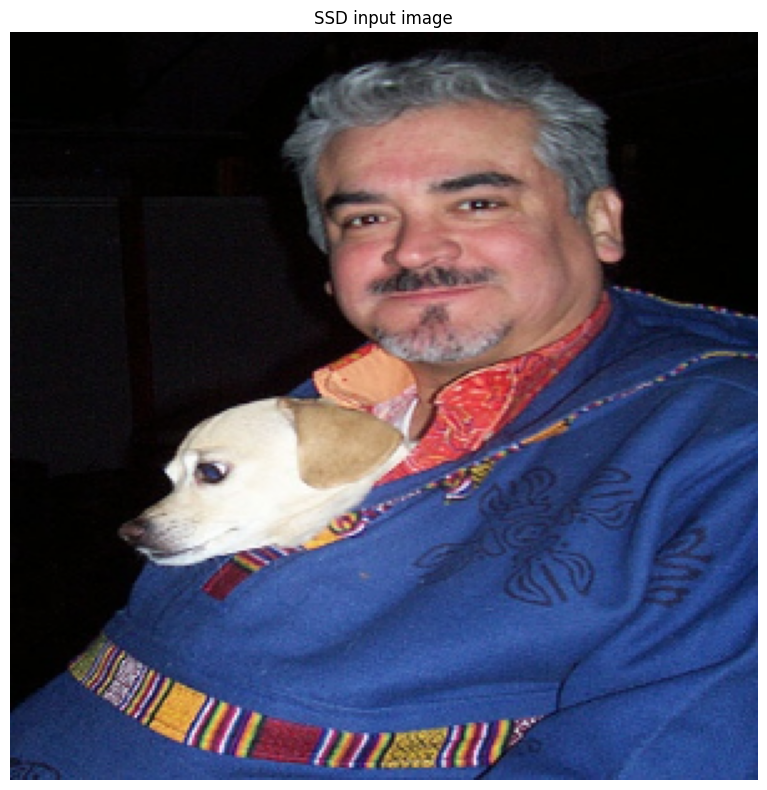

Saved: outputs/inference_input.png


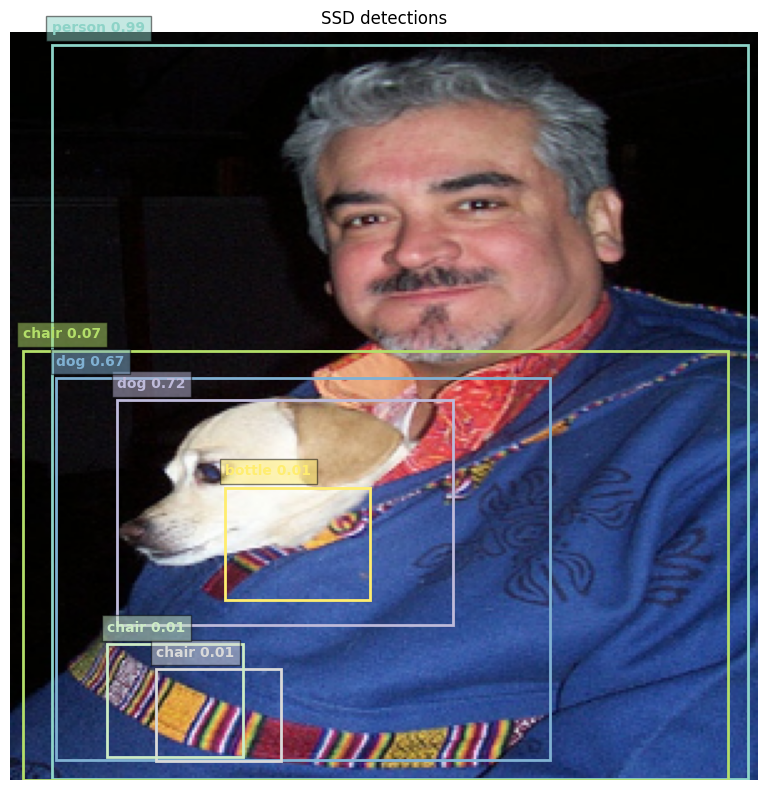

Saved: outputs/detection_result.png


In [ ]:
print("Running inference on the first test image...")
image_tensor, det = run_inference(model, test_loader, device, cfg)

# Always save the input image
image = denorm_image(image_tensor, cfg.INPUT.PIXEL_MEAN)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(image)
ax.set_title("SSD input image")
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/inference_input.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/inference_input.png")

boxes = det["boxes"]
labels = det["labels"]
scores = det["scores"]
if boxes.numel() == 0:
    print("No detections above threshold.")
else:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image)
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        xmin, ymin, xmax, ymax = box.cpu().numpy()
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor=colors[i], facecolor="none")
        ax.add_patch(rect)
        class_name = VOC_CLASSES[int(label)]
        text = f"{class_name} {score.item():.2f}"
        ax.text(xmin, ymin - 5, text, color=colors[i], fontsize=10, weight="bold", bbox=dict(facecolor=colors[i], alpha=0.5))
    ax.set_title("SSD detections")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("outputs/detection_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: outputs/detection_result.png")

---
## 项目总结与延伸思考

恭喜你！通过本项目，你已经完整体验了从底层逻辑到高层封装的 SSD 实现。通过本项目，我们不仅学会了如何构建复杂的 CNN 网络，更深入理解了目标检测中的样本失衡处理、多尺度特征融合等工程设计思想。

### 延伸思考
**Q1：为什么 SSD 在检测非常细小的物体（如测试图一）时效果相对较弱？**
> **参考回答：** SSD 依赖第一层特征图 (38x38) 来检测。对于极小物体，经过多次池化后，特征在底层特征图上的分辨率已经不足，且缺乏充分的语义上下文。相比之下，FPN（特征金字塔网络）通过上采样融合深浅层特征，能更好地解决这一问题。

**Q2：如果我们将 `max_iter` 的 Batch Size 减半，我们需要对 `SOLVER.LR` 做什么调整？**
> **参考回答：** 根据线性缩放规则（Linear Scaling Rule），如果 Batch Size 减半，通常建议将学习率也相应减半，以保持梯度更新的稳定性和方差一致。

**Q3：什么是损失函数中的 Hard Negative Mining？不加它会怎样？**
> **参考回答：** 它是为了筛选出对模型最具挑战性的负样本（背景）。不加它，由于背景框数量远超物体框，训练过程中正样本的损失会被海量的低质量负样本“淹没”，导致模型虽然能识别背景，但无法有效定位物体。

**Q4：在本项目的实验结果中，我们观察到袖子的纹路被误认为是 `chair`，且同一只狗出现了两个重叠框。这反映了什么问题？**
> **参考回答：** 
> 1. **误检（袖子变椅子）：** 反映了模型的**特征表达能力不足**。模型仅通过局部纹理判断，缺乏全局上下文理解。可以通过使用更强的骨干网络（如 ResNet）或多尺度特征融合来改善。
> 2. **重复检测（两个狗框）：** 反映了 **NMS（非极大值抑制）未生效或配置不当**。可能是两个框的 IoU 刚好低于设定的阈值，或者回归器对不同 Scale 的 Anchor 都给出了极高的置信度。可以尝试微调 `NMS_THRESHOLD` 或使用更先进的 Soft-NMS。